In [25]:
%load_ext autoreload
%autoreload 2
%aimport load.loader

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

from load.loader import ArcadeDataset
from parse.parser import ArcadeParser

In [28]:
keys = ["C_Lava_"]

In [30]:
parser = ArcadeParser()
# parser.parse_files_to_csv(keys=keys)
# parser.parse_graph_metrics_to_csv(keys=keys)
parser.parse_cell_metrics_to_csv(keys=keys)

seed:  0
seed:  1
seed:  2
seed:  3
seed:  4
seed:  5
seed:  6
seed:  7
seed:  8
seed:  9
seed:  10
seed:  11
seed:  12
seed:  13
seed:  14
seed:  15
seed:  16
seed:  17
seed:  18
seed:  19
seed:  20
seed:  21
seed:  22
seed:  23
seed:  24
seed:  25
seed:  26
seed:  27
seed:  28
seed:  29
seed:  30
seed:  31
seed:  32
seed:  33
seed:  34
seed:  35
seed:  36
seed:  37
seed:  38
seed:  39
seed:  40
seed:  41
seed:  42
seed:  43
seed:  44
seed:  45
seed:  46
seed:  47
seed:  48
seed:  49
seed:  50
seed:  51
seed:  52
seed:  53
seed:  54
seed:  55
seed:  56
seed:  57
seed:  58
seed:  59
seed:  60
seed:  61
seed:  62
seed:  63
seed:  64
seed:  65
seed:  66
seed:  67
seed:  68
seed:  69
seed:  70
seed:  71
seed:  72
seed:  73
seed:  74
seed:  75
seed:  76
seed:  77
seed:  78
seed:  79
seed:  80
seed:  81
seed:  82
seed:  83
seed:  84
seed:  85
seed:  86
seed:  87
seed:  88
seed:  89
seed:  90
seed:  91
seed:  92
seed:  93
seed:  94
seed:  95
seed:  96
seed:  97
seed:  98
seed:  99


FileNotFoundError: [Errno 2] No such file or directory: '../../rdata/ARCADE/C_Lava_cell.csv'

In [5]:
dataset = ArcadeDataset(keys, split_ratio=0.2)
print(f"{len(dataset)} samples in dataset")

train_subset = dataset.train_subset()
test_subset = dataset.test_subset()

print(f"{len(train_subset)} samples in train subset")
print(f"{len(test_subset)} samples in test subset")

train_loader = DataLoader(train_subset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=1, shuffle=True)

3100 samples in dataset
2480 samples in train subset
620 samples in test subset


# PCA

In [16]:
def filter_features_by_seed(seeds, features, labels):
    filtered_features = []
    filtered_labels = []
    
    for feature, label in zip(features, labels):
        if label['seed'] in seeds:
            filtered_features.append(feature)
            filtered_labels.append(label)
    
    return filtered_features, filtered_labels

def filter_features_by_timepoint(timepoints, features, labels):
    filtered_features = []
    filtered_labels = []
    
    for feature, label in zip(features, labels):
        if label['timepoint'] in timepoints:
            filtered_features.append(feature)
            filtered_labels.append(label)
    
    return filtered_features, filtered_labels

In [19]:
timepoints_after_first_day = [(x / 2.0) for x in range(2, 31)]

train_features = []
train_labels = []
for X, y in train_loader:
    train_features.append(X[0])
    train_labels.append(y)

# Remove samples with inf
train_features = np.array(train_features)
train_features = train_features[~np.isinf(train_features).any(axis=1)]
train_features, train_labels = filter_features_by_timepoint(timepoints_after_first_day, train_features, train_labels)
print(f"{len(train_features)} samples in train features after removing inf")

num_components = 2
pca = PCA(n_components=num_components)
pca.fit(train_features)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

2318 samples in train features after removing inf
Explained variance ratio: [0.93940231 0.05571103]


580
580 samples in test features after removing inf


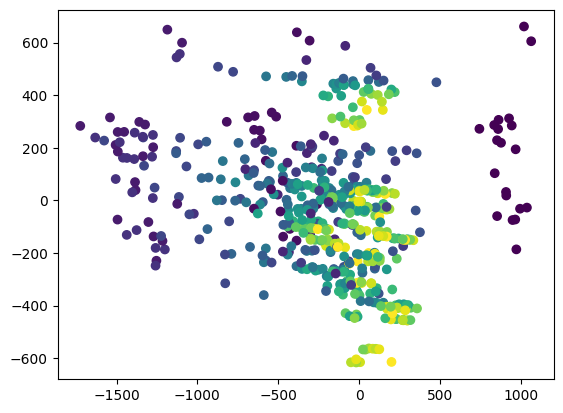

In [24]:
# Plot a test sample in the PCA space
test_features = []
test_labels = []
for X, y in test_loader:
    test_features.append(X[0])
    test_labels.append(y)

test_features = np.array(test_features)
test_labels = np.array(test_labels)
inf_indices = np.isinf(test_features).any(axis=1)
test_features = test_features[~inf_indices]
test_labels = test_labels[~inf_indices]


seed_labels = [label['seed'] for label in test_labels]
# test_features, test_labels = filter_features_by_seed([seed_labels[0], seed_labels[1], seed_labels[2]], test_features, test_labels)
test_features, test_labels = filter_features_by_timepoint(timepoints_after_first_day, test_features, test_labels)
timepoint_labels = [label['timepoint'] for label in test_labels]
print(len(test_labels))

print(f"{len(test_features)} samples in test features after removing inf")

test_features_pca = pca.transform(test_features)

plt.scatter(test_features_pca[:, 0], test_features_pca[:, 1], c=timepoint_labels)
plt.show()